# Import library

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load datasets

In [120]:
df = pd.read_csv('/content/sample_data/Starship_Safety.csv')
df.tail(50)

,f1_hex_code,f2_temp_log,f3_wave_phase,f4_micro_metric,f5_sector_class,f6_launch_date,f7_power_skew,f8_bimodal_core,f9_cargo_path,f10_status_mix,f11_sync_clock,f12_spatial_coord,f13_noisy_base,f14_crew_code,f15_parity_bit,target_breach
950,0x3d1,Temp: 35.90 C,1.911609,17.574210,Gamma,2028-08-08,0.142348,19.269518,D-A-C-D,FALSE,70263.0,"(3, 1)",270.0,oueiyeuy,690.0,1
951,0x64,Temp: 45.92 C,47.684347,44.318186,Gamma,2028-08-09,1.287246,-16.657660,D,T,84855.0,"(18, 18)",620.0,yooaazoo,573.0,1
952,0x96,Temp: 19.74 C,68.772204,16.322105,Alpha,2028-08-10,1.039236,24.071747,A-C-D,F,26575.0,"(4, 15)",297.0,xyaaeoyo,936.0,0
953,0x310,Temp: 47.08 C,72.270696,28.760586,Delta,2028-08-11,4.218506,20.937956,C-B,F,22204.0,"(19, 19)",925.0,ueiiiyxa,3.0,0
954,0x330,Temp: 12.41 C,69.253243,30.413554,Beta,2028-08-12,0.446669,19.016086,A-B,FALSE,21952.0,"(10, 5)",292.0,yiuzyyza,594.0,0
955,0x367,Temp: 47.38 C,13.443513,51.750542,Gamma,2028-08-13,0.004050,-22.656114,C-B-A,1,NaN,"(19, 11)",202.0,aiazezze,263.0,1
956,0x221,Temp: 24.06 C,29.939559,33.902033,Delta,2028-08-14,0.272990,18.054471,C-B-B,TRUE,61142.0,"(7, 5)",790.0,ziyuaoyi,799.0,0
957,0x224,Temp: 14.06 C,35.871553,18.987052,Beta,2028-08-15,10.820640,20.813244,C,T,43872.0,"(12, 19)",594.0,xaiziuoa,321.0,1
958,0x3d4,Temp: 29.43 C,80.443721,24.906707,Beta,2028-08-16,0.409783,-19.654742,A-D-A,TRUE,39376.0,"(15, 12)",796.0,iiyaziii,607.0,1
959,0x24b,Temp: 20.27 C,27.875987,23.107525,Beta,2028-08-17,0.477520,-21.277354,A-A-D-D-A,FALSE,76084.0,"(4, 12)",706.0,eeouyyau,576.0,1


# Basic EDA

In [121]:
df.columns

Index(['f1_hex_code', 'f2_temp_log', 'f3_wave_phase', 'f4_micro_metric',
       'f5_sector_class', 'f6_launch_date', 'f7_power_skew', 'f8_bimodal_core',
       'f9_cargo_path', 'f10_status_mix', 'f11_sync_clock',
       'f12_spatial_coord', 'f13_noisy_base', 'f14_crew_code',
       'f15_parity_bit', 'target_breach'],
      dtype='object')

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   f1_hex_code        1000 non-null   object 
 1   f2_temp_log        997 non-null    object 
 2   f3_wave_phase      998 non-null    float64
 3   f4_micro_metric    998 non-null    float64
 4   f5_sector_class    999 non-null    object 
 5   f6_launch_date     999 non-null    object 
 6   f7_power_skew      998 non-null    float64
 7   f8_bimodal_core    998 non-null    float64
 8   f9_cargo_path      1000 non-null   object 
 9   f10_status_mix     1000 non-null   object 
 10  f11_sync_clock     999 non-null    float64
 11  f12_spatial_coord  1000 non-null   object 
 12  f13_noisy_base     999 non-null    float64
 13  f14_crew_code      999 non-null    object 
 14  f15_parity_bit     998 non-null    float64
 15  target_breach      1000 non-null   object 
dtypes: float64(7), object(9)


In [123]:
df.describe()

,f3_wave_phase,f4_micro_metric,f7_power_skew,f8_bimodal_core,f11_sync_clock,f13_noisy_base,f15_parity_bit
count,998.000000,998.000000,998.000000,998.000000,999.000000,999.000000,998.000000
mean,49.833923,54.222814,71.714402,-0.011687,54819.540541,499.518519,524.769539
std,28.809858,25.707701,716.064682,20.072703,27032.827988,257.753792,450.170623
min,0.156511,10.001035,0.000121,-26.225820,10005.000000,60.000000,2.000000
25%,25.513548,32.105651,0.112911,-19.913578,30112.000000,287.000000,241.250000
50%,50.565391,54.544710,0.995937,-14.701437,55344.000000,501.000000,505.000000
75%,74.519882,76.102473,7.292835,20.024900,79273.000000,723.000000,782.000000
max,99.834751,98.901442,16802.431860,26.153721,99987.000000,939.000000,6545.000000


In [124]:
df.nunique()

,0
f1_hex_code,585
f2_temp_log,880
f3_wave_phase,998
f4_micro_metric,998
f5_sector_class,4
f6_launch_date,999
f7_power_skew,998
f8_bimodal_core,998
f9_cargo_path,409
f10_status_mix,6


In [125]:
df.shape

(1000, 16)

# Missing Value

In [126]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]
missing = missing.sort_values("Missing %", ascending=False)

missing

,Missing Count,Missing %
f2_temp_log,3,0.3
f3_wave_phase,2,0.2
f4_micro_metric,2,0.2
f8_bimodal_core,2,0.2
f7_power_skew,2,0.2
f15_parity_bit,2,0.2
f6_launch_date,1,0.1
f5_sector_class,1,0.1
f11_sync_clock,1,0.1
f13_noisy_base,1,0.1


In [127]:
df['target_breach']

,target_breach
0,0
1,1
2,1
3,1
4,0
...,...
995,0
996,0
997,1
998,0


# Split the shape

# Encoding target column

In [128]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assume your target column is named 'target_column'
le = LabelEncoder()

# Fit and transform the target variable
df['target_breach'] = le.fit_transform(df['target_breach'])


In [129]:
X = df.drop('target_breach', axis=1)
y = df['target_breach']

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,

)

In [131]:
X_train.shape

(800, 15)

# Divide Numeric and catg column

In [132]:
num_cols= X.select_dtypes(include=['number']).columns

catg_cols = X.select_dtypes(include=['object','category']).columns

In [133]:
num_cols

Index(['f3_wave_phase', 'f4_micro_metric', 'f7_power_skew', 'f8_bimodal_core',
       'f11_sync_clock', 'f13_noisy_base', 'f15_parity_bit'],
      dtype='object')

In [134]:
catg_cols

Index(['f1_hex_code', 'f2_temp_log', 'f5_sector_class', 'f6_launch_date',
       'f9_cargo_path', 'f10_status_mix', 'f12_spatial_coord',
       'f14_crew_code'],
      dtype='object')

## Distribution  before impution

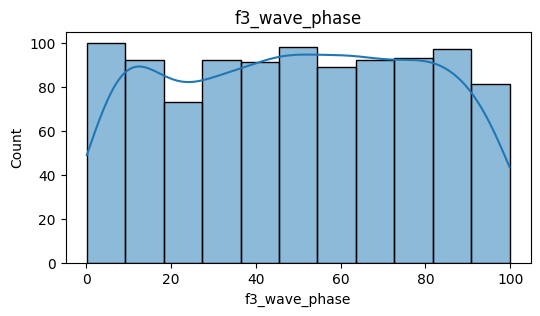

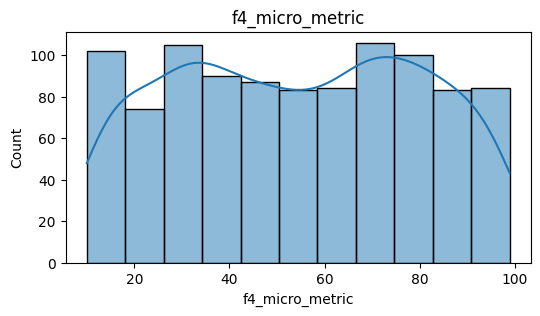

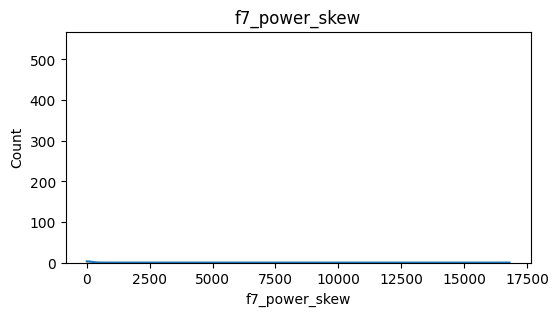

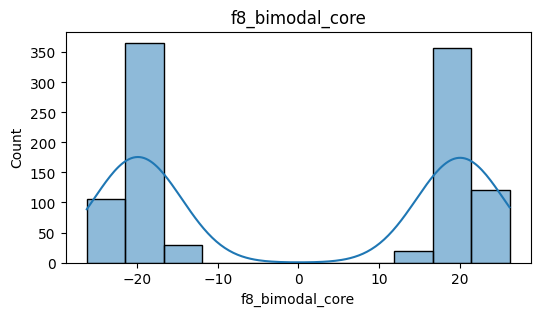

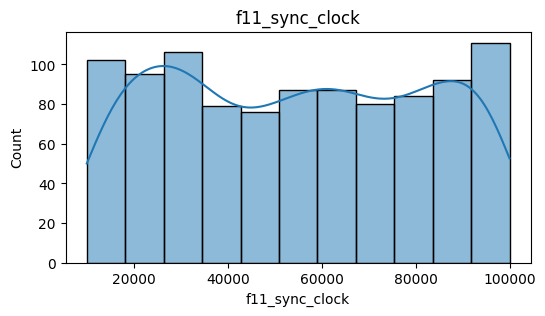

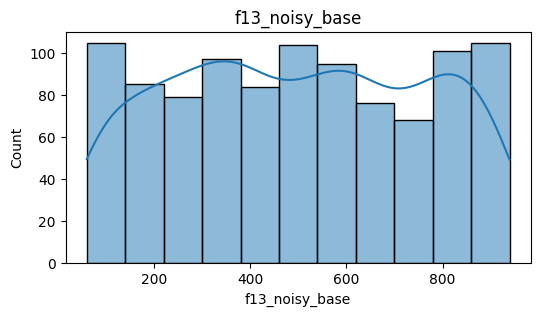

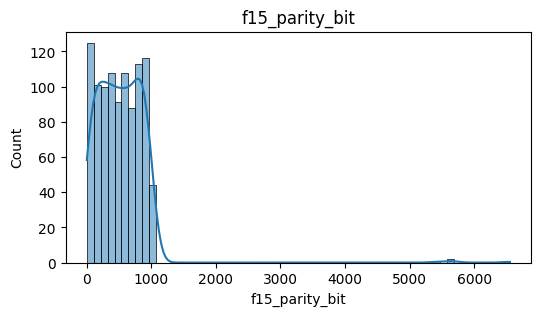

In [135]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

> Skewness

# Handling missing value

 > Import library

In [137]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

## Numeric_pipeline

In [138]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

## Catg_Pipeline

In [139]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

# Combine them

In [140]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, catg_cols)
])

# Train A Baseline Model

# Random Forest

In [141]:
from sklearn.ensemble import RandomForestClassifier

RF_Pipeline = Pipeline([
    ("Preprocessor",preprocessor),
    ("Classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state= 42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

## Train the model

In [142]:
RF_Pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f3_wave_phase', 'f4_micro_metric', 'f7_power_skew', 'f8_bimodal_core',
       'f11_sync_clock', 'f13_noisy_base', 'f15_parity_bit'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 str...onstant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['f1_hex_code', 'f2_temp_log', 'f5_sector_class', 'f6_launch_date',
       'f9_cargo_path', 'f10_status_mix', 'f12_spatial_coord',
       'f14_crew_code'],
      dtype='object'))])),
                ('Classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## Make prediction

In [143]:
RF_pred = RF_Pipeline.predict(X_test)
RF_proba = RF_Pipeline.predict_proba(X_test)[:, 1]

## Model Evaluation

In [144]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, RF_pred))
print("Precision:", precision_score(y_test, RF_pred,average='weighted'))
print("Recall   :", recall_score(y_test, RF_pred,average='weighted'))
print("F1 Score :", f1_score(y_test, RF_pred,average='weighted'))


print(confusion_matrix(y_test, RF_pred))

print(classification_report(y_test, RF_pred))

Accuracy : 0.685
Precision: 0.6828521303258145
Recall   : 0.685
F1 Score : 0.681444048791575
[[68 24  0  0]
 [37 69  0  0]
 [ 0  1  0  0]
 [ 0  1  0  0]]
              precision    recall  f1-score   support

           0       0.65      0.74      0.69        92
           1       0.73      0.65      0.69       106
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.69       200
   macro avg       0.34      0.35      0.34       200
weighted avg       0.68      0.69      0.68       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# XGBoost

## define model + pipeline

In [145]:
from xgboost import XGBClassifier

XGB_Pipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("Classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",     # matches your AUC-PR focus
        random_state=42,
        n_jobs=-1
    ))
])

## Train model

In [146]:
XGB_Pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['f3_wave_phase', 'f4_micro_metric', 'f7_power_skew', 'f8_bimodal_core',
       'f11_sync_clock', 'f13_noisy_base', 'f15_parity_bit'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 str...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Prediction

In [147]:
xgb_pred = XGB_Pipeline.predict(X_test)
xgb_proba = XGB_Pipeline.predict_proba(X_test)[:, 1]

## Evaluate

In [148]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, accuracy_score,
    confusion_matrix, classification_report
)

print("Accuracy :", accuracy_score(y_test, RF_pred))
print("Precision:", precision_score(y_test, RF_pred,average='weighted'))
print("Recall   :", recall_score(y_test, RF_pred,average='weighted'))
print("F1 Score :", f1_score(y_test, RF_pred,average='weighted'))


print()
print(classification_report(y_test, xgb_pred))

Accuracy : 0.685
Precision: 0.6828521303258145
Recall   : 0.685
F1 Score : 0.681444048791575

              precision    recall  f1-score   support

           0       0.63      0.64      0.64        92
           1       0.68      0.69      0.69       106
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.66       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.65      0.66      0.66       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# The Best model I choose is XGBoost